## 1. Analysis Objectives

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 120)

# If this notebook is inside notebooks/, project root is one level up.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
DATA_FEATURES = PROJECT_ROOT / 'data' / 'features'
DATA_MULTILINGUAL = PROJECT_ROOT / 'data' / 'multilingual'
REPORT_FIGURES = PROJECT_ROOT / 'reports' / 'figures'
REPORT_FIGURES.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)

Project root: d:\CSCI4018 - Research project - Phishing Email Detection


## 2. Load Prepared Datasets

In [2]:
master_df = pd.read_csv(DATA_PROCESSED / 'master_dataset.csv')
print('Master dataset:', master_df.shape)
master_df.head()

Master dataset: (40063, 13)


,email_id,source_dataset,sender,receiver,date,subject,body,email_text,urls,original_label,category,label,language
0,1,Enron,NaN,NaN,NaN,"hpl nom for may 25 , 2001",( see attached file : hplno 525 . xls ) - hplno 525 . xls,"hpl nom for may 25 , 2001 ( see attached file : hplno 525 . xls ) - hplno 525 . xls",NaN,0,Legitimate,0,English
1,2,Enron,NaN,NaN,NaN,re : nom / actual vols for 24 th,- - - - - - - - - - - - - - - - - - - - - - forwarded by sabrae zajac / hou / ect on 05 / 30 / 2001 12 : 07 pm - - -...,re : nom / actual vols for 24 th - - - - - - - - - - - - - - - - - - - - - - forwarded by sabrae zajac / hou / ect o...,NaN,0,Legitimate,0,English
2,3,Enron,NaN,NaN,NaN,"enron actuals for march 30 - april 1 , 201","estimated actuals march 30 , 2001 no flow march 31 , 2001 no flow april 1 , 2001 teco tap 35 . 000 when i receive th...","enron actuals for march 30 - april 1 , 201 estimated actuals march 30 , 2001 no flow march 31 , 2001 no flow april 1...",NaN,0,Legitimate,0,English
3,4,Enron,NaN,NaN,NaN,"hpl nom for may 30 , 2001",( see attached file : hplno 530 . xls ) - hplno 530 . xls,"hpl nom for may 30 , 2001 ( see attached file : hplno 530 . xls ) - hplno 530 . xls",NaN,0,Legitimate,0,English
4,5,Enron,NaN,NaN,NaN,"hpl nom for june 1 , 2001",( see attached file : hplno 601 . xls ) - hplno 601 . xls,"hpl nom for june 1 , 2001 ( see attached file : hplno 601 . xls ) - hplno 601 . xls",NaN,0,Legitimate,0,English


## 3. Dataset Columns and Label Mapping

In [3]:
print('Columns:')
print(master_df.columns.tolist())

label_mapping = master_df[['category', 'label']].drop_duplicates().sort_values('label')
label_mapping

Columns:
['email_id', 'source_dataset', 'sender', 'receiver', 'date', 'subject', 'body', 'email_text', 'urls', 'original_label', 'category', 'label', 'language']


,category,label
0,Legitimate,0
3405,Spam,1
35223,Traditional_Phishing,2
36771,Business_Email_Compromise,3


## 4. Class Distribution in Master Dataset

In [4]:
class_counts = master_df['category'].value_counts()
class_percent = (master_df['category'].value_counts(normalize=True) * 100).round(2)

class_summary = pd.DataFrame({
    'count': class_counts,
    'percentage': class_percent
})
class_summary

,count,percentage
category,,
Legitimate,19564,48.83
Spam,15659,39.09
Business_Email_Compromise,3292,8.22
Traditional_Phishing,1548,3.86


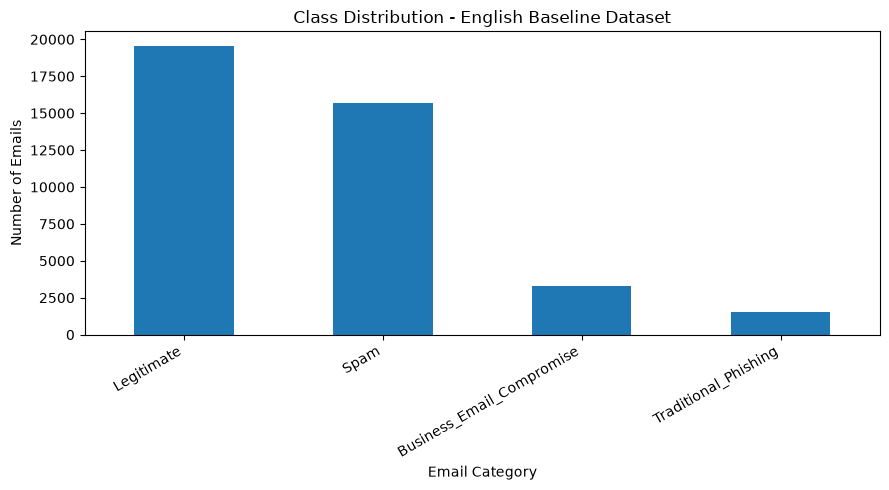

In [5]:
plt.figure(figsize=(9, 5))
class_counts.plot(kind='bar')
plt.title('Class Distribution - English Baseline Dataset')
plt.xlabel('Email Category')
plt.ylabel('Number of Emails')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(REPORT_FIGURES / 'class_distribution_english_baseline.png', dpi=200)
plt.show()

## 5. Missing Value Analysis

In [6]:
missing_values = master_df.isna().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

receiver    31032
date        29901
sender      29752
urls        29423
subject       257
dtype: int64

## 6. Handling Missing Values

In [7]:
import pandas as pd

# Copy dataset before handling missing values
clean_df = master_df.copy()

# 1. Fill important text columns
clean_df["subject"] = clean_df["subject"].fillna("")
clean_df["body"] = clean_df["body"].fillna("")

# 2. Fill metadata columns
if "sender" in clean_df.columns:
    clean_df["sender"] = clean_df["sender"].fillna("unknown_sender")

if "receiver" in clean_df.columns:
    clean_df["receiver"] = clean_df["receiver"].fillna("unknown_receiver")

if "date" in clean_df.columns:
    clean_df["date"] = clean_df["date"].fillna("unknown_date")

# 3. Handle URL column
if "urls" in clean_df.columns:
    clean_df["urls"] = pd.to_numeric(clean_df["urls"], errors="coerce").fillna(0).astype(int)

# 4. Remove rows only if both subject and body are empty
clean_df = clean_df[
    ~((clean_df["subject"].str.strip() == "") & (clean_df["body"].str.strip() == ""))
].copy()

# 5. Recreate email_text column
clean_df["email_text"] = (
    clean_df["subject"].fillna("") + " " + clean_df["body"].fillna("")
).str.strip()

# 6. Check missing values again
missing_after = clean_df.isna().sum().sort_values(ascending=False)
missing_after[missing_after > 0]

Series([], dtype: int64)

In [8]:
clean_df["sender_missing"] = (clean_df["sender"] == "unknown_sender").astype(int)
clean_df["receiver_missing"] = (clean_df["receiver"] == "unknown_receiver").astype(int)
clean_df["date_missing"] = (clean_df["date"] == "unknown_date").astype(int)

clean_df[[
    "sender_missing",
    "receiver_missing",
    "date_missing"
]].sum()

sender_missing      29752
receiver_missing    31032
date_missing        29901
dtype: int64

#### This section creates indicator features to record whether sender, receiver, and date values were originally missing. These features are useful for analysis, but they should be used carefully during model training to avoid dataset-source leakage.

In [9]:
missing_after = clean_df.isna().sum().sort_values(ascending=False)
missing_after[missing_after > 0]

Series([], dtype: int64)

## 7. Checking duplicated values

In [10]:
import pandas as pd

master_df = pd.read_csv("../data/processed/master_dataset.csv", low_memory=False)

print("Dataset shape:", master_df.shape)

print("Duplicate email_text rows:", master_df.duplicated(subset=["email_text"]).sum())
print("Duplicate subject + body rows:", master_df.duplicated(subset=["subject", "body"]).sum())
print("Duplicate body rows:", master_df.duplicated(subset=["body"]).sum())
print("Duplicate subject rows:", master_df.duplicated(subset=["subject"]).sum())

Dataset shape: (40063, 13)
Duplicate email_text rows: 0
Duplicate subject + body rows: 0
Duplicate body rows: 124
Duplicate subject rows: 8531


#### Duplicate analysis showed that there were no duplicate full email records based on email_text or subject + body. Some repeated subjects and body values were found, but repeated subjects are expected in email datasets. Therefore, no additional rows were removed at this stage based on full email duplication.

In [11]:
clean_df.to_csv("../data/processed/master_dataset_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")
print("Final shape:", clean_df.shape)

Cleaned dataset saved successfully.
Final shape: (40063, 16)


#### This section saves the cleaned dataset as `master_dataset_cleaned.csv`. This cleaned dataset can be used for feature engineering and future experiments.

## 8. Text Length Analysis

Text length helps identify extremely short or unusually long emails that may affect model training.

In [12]:
clean_df['email_text'] = clean_df['subject'].fillna('') + ' ' + clean_df['body'].fillna('')
clean_df['text_char_count'] = clean_df['email_text'].str.len()
clean_df['text_word_count'] = clean_df['email_text'].str.split().apply(len)

clean_df.groupby('category')[['text_char_count', 'text_word_count']].describe().round(2)

text_char_count                                    \
                                    count     mean       std   min      25%   
category                                                                      
Business_Email_Compromise          3292.0  2631.34   2470.01  53.0  1872.50   
Legitimate                        19564.0  1716.88   5721.22  16.0   383.75   
Spam                              15659.0  1548.50   3748.38   3.0   387.00   
Traditional_Phishing               1548.0  1755.85  26022.10  34.0   422.00   

                                                      text_word_count          \
                              50%      75%        max           count    mean   
category                                                                        
Business_Email_Compromise  2533.5  3200.25   122708.0          3292.0  447.56   
Legitimate                  855.0  1691.00   299268.0         19564.0  336.06   
Spam                        732.0  1577.00   230889.0         15659.0  277.99   
Traditional_Phishing        730.5  1212.25  1023603.0          1548.0  193.20   

                                                                        
                               std   min    25%    50%    75%      max  
category                                                                
Business_Email_Compromise   456.24  10.0  316.0  433.5  542.0  23486.0  
Legitimate                 1012.10   3.0   76.0  168.0  348.0  45450.0  
Spam                        430.45   2.0   77.0  144.0  294.5  11627.0  
Traditional_Phishing       1196.55   3.0   62.0  108.5  186.0  46579.0

<Figure size 900x500 with 0 Axes>

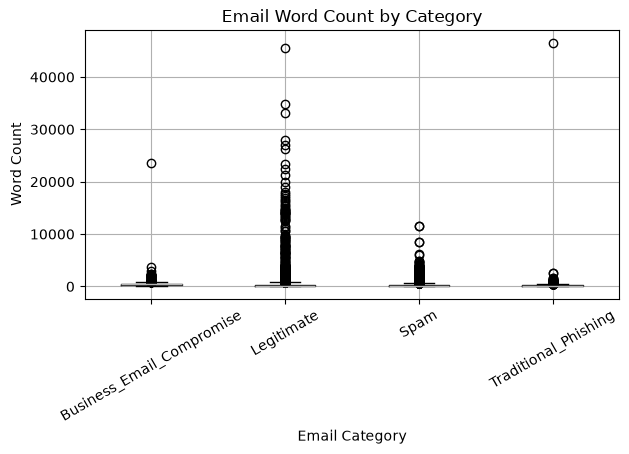

In [13]:
plt.figure(figsize=(9, 5))
clean_df.boxplot(column='text_word_count', by='category', rot=30)
plt.title('Email Word Count by Category')
plt.suptitle('')
plt.xlabel('Email Category')
plt.ylabel('Word Count')
plt.tight_layout()
plt.savefig(REPORT_FIGURES / 'word_count_by_category.png', dpi=200)
plt.show()

## 9. Load Feature-Engineered Dataset

In [14]:
features_df = pd.read_csv(DATA_FEATURES / 'master_features.csv')

print('Feature dataset shape:', features_df.shape)
features_df.head()

Feature dataset shape: (40063, 28)


,email_id,source_dataset,sender,receiver,date,subject,body,email_text,urls,original_label,category,label,language,sender_missing,receiver_missing,date_missing,clean_email_text,extracted_urls,url_count_extracted,has_url,has_defanged_url,text_char_count,text_word_count,subject_char_count,body_char_count,suspicious_keyword_count,email_entropy,detected_language
0,1,Enron,unknown_sender,unknown_receiver,unknown_date,"hpl nom for may 25 , 2001",( see attached file : hplno 525 . xls ) - hplno 525 . xls,"hpl nom for may 25 , 2001 ( see attached file : hplno 525 . xls ) - hplno 525 . xls",0,0,Legitimate,0,English,1,1,1,"hpl nom for may 25 , 2001 ( see attached file : hplno 525 . xls ) - hplno 525 . xls",NaN,0,0,0,83,22,25,57,0,4.1777,English
1,2,Enron,unknown_sender,unknown_receiver,unknown_date,re : nom / actual vols for 24 th,- - - - - - - - - - - - - - - - - - - - - - forwarded by sabrae zajac / hou / ect on 05 / 30 / 2001 12 : 07 pm - - -...,re : nom / actual vols for 24 th - - - - - - - - - - - - - - - - - - - - - - forwarded by sabrae zajac / hou / ect o...,0,0,Legitimate,0,English,1,1,1,re : nom / actual vols for 24 th - - - - - - - - - - - - - - - - - - - - - - forwarded by sabrae zajac / hou / ect o...,NaN,0,0,0,1607,435,32,1574,0,4.4431,English
2,3,Enron,unknown_sender,unknown_receiver,unknown_date,"enron actuals for march 30 - april 1 , 201","estimated actuals march 30 , 2001 no flow march 31 , 2001 no flow april 1 , 2001 teco tap 35 . 000 when i receive th...","enron actuals for march 30 - april 1 , 201 estimated actuals march 30 , 2001 no flow march 31 , 2001 no flow april 1...",0,0,Legitimate,0,English,1,1,1,"enron actuals for march 30 - april 1 , 201 estimated actuals march 30 , 2001 no flow march 31 , 2001 no flow april 1...",NaN,0,0,0,207,47,42,164,0,4.2607,English
3,4,Enron,unknown_sender,unknown_receiver,unknown_date,"hpl nom for may 30 , 2001",( see attached file : hplno 530 . xls ) - hplno 530 . xls,"hpl nom for may 30 , 2001 ( see attached file : hplno 530 . xls ) - hplno 530 . xls",0,0,Legitimate,0,English,1,1,1,"hpl nom for may 30 , 2001 ( see attached file : hplno 530 . xls ) - hplno 530 . xls",NaN,0,0,0,83,22,25,57,0,4.2168,English
4,5,Enron,unknown_sender,unknown_receiver,unknown_date,"hpl nom for june 1 , 2001",( see attached file : hplno 601 . xls ) - hplno 601 . xls,"hpl nom for june 1 , 2001 ( see attached file : hplno 601 . xls ) - hplno 601 . xls",0,0,Legitimate,0,English,1,1,1,"hpl nom for june 1 , 2001 ( see attached file : hplno 601 . xls ) - hplno 601 . xls",NaN,0,0,0,83,22,25,57,0,4.1959,English


## 10. Engineered Feature Summary

In [15]:
feature_columns = [
    'url_count_extracted',
    'has_url',
    'has_defanged_url',
    'text_char_count',
    'text_word_count',
    'suspicious_keyword_count',
    'email_entropy'
]

features_df.groupby('category')[feature_columns].mean().round(2)

,url_count_extracted,has_url,has_defanged_url,text_char_count,text_word_count,suspicious_keyword_count,email_entropy
category,,,,,,,
Business_Email_Compromise,0.58,0.37,0.0,2630.64,447.55,2.99,4.32
Legitimate,1.00,0.18,0.0,1712.89,335.52,0.50,4.33
Spam,0.25,0.07,0.0,1544.59,277.44,0.74,4.29
Traditional_Phishing,0.33,0.16,0.0,1753.55,192.85,3.13,4.44


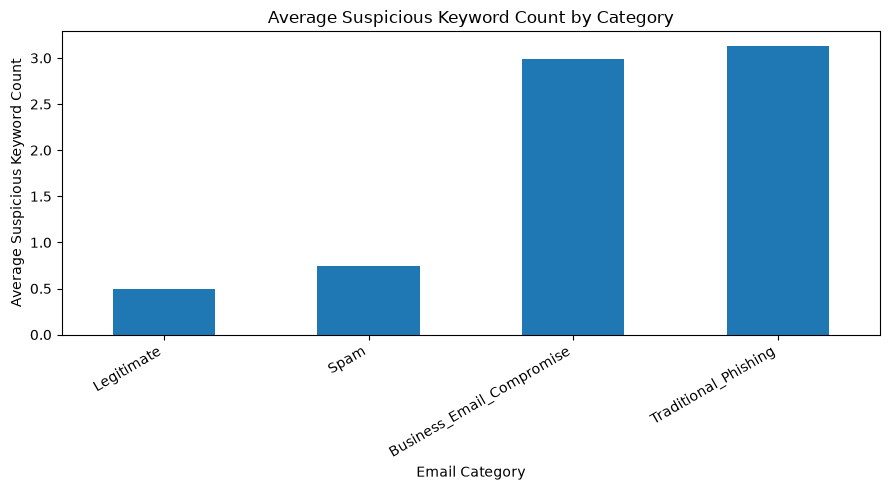

In [16]:
plt.figure(figsize=(9, 5))
features_df.groupby('category')['suspicious_keyword_count'].mean().sort_values().plot(kind='bar')
plt.title('Average Suspicious Keyword Count by Category')
plt.xlabel('Email Category')
plt.ylabel('Average Suspicious Keyword Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(REPORT_FIGURES / 'suspicious_keyword_count_by_category.png', dpi=200)
plt.show()

## 11. Language Distribution

In [17]:
features_df['detected_language'].value_counts()

detected_language
English    40061
Unknown        2
Name: count, dtype: int64

## 12. Train / Validation / Test Split Check



#### Load the split files

In [18]:
train_df = pd.read_csv(DATA_FEATURES / "train_features.csv")
val_df = pd.read_csv(DATA_FEATURES / "validation_features.csv")
test_df = pd.read_csv(DATA_FEATURES / "test_features.csv")

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (28044, 28)
Validation shape: (6009, 28)
Test shape: (6010, 28)


#### Split summary table

In [19]:
split_summary = pd.DataFrame({
    "train": train_df["category"].value_counts(),
    "validation": val_df["category"].value_counts(),
    "test": test_df["category"].value_counts()
}).fillna(0).astype(int)

split_summary["total"] = split_summary.sum(axis=1)

split_summary

,train,validation,test,total
category,,,,
Legitimate,13695,2934,2935,19564
Spam,10961,2349,2349,15659
Business_Email_Compromise,2304,494,494,3292
Traditional_Phishing,1084,232,232,1548


#### Split percentage table

In [20]:
split_percentage = split_summary[["train", "validation", "test"]].div(
    split_summary["total"], axis=0
) * 100

split_percentage = split_percentage.round(2)

split_percentage

,train,validation,test
category,,,
Legitimate,70.00,15.00,15.00
Spam,70.00,15.00,15.00
Business_Email_Compromise,69.99,15.01,15.01
Traditional_Phishing,70.03,14.99,14.99


#### Split Distribution Chart

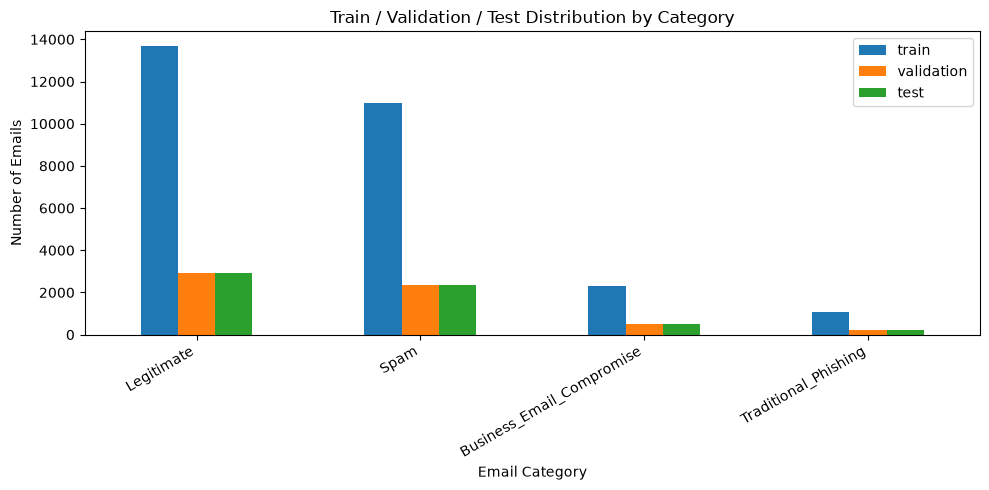

In [21]:
split_summary[["train", "validation", "test"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Train / Validation / Test Distribution by Category")
plt.xlabel("Email Category")
plt.ylabel("Number of Emails")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(REPORT_FIGURES / "split_distribution.png", dpi=200)
plt.show()

#### The train, validation, and test split check confirms that all email categories are represented in each split. The class distribution remains consistent across the three datasets, which supports fair model training and evaluation.